<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula5d_reuters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from tensorflow import keras
from tensorflow.keras.datasets import reuters
from sklearn.metrics import accuracy_score
import numpy as np

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000, test_split=0.2)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
print(len(train_data))
print(len(test_data))

8982
2246


In [3]:
train_data[:2]

array([list([1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 2, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 2, 49, 2295, 2, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 2, 2, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12])],
      dtype=object)

In [4]:
print(len(train_data[0]))
print(len(train_data[1]))

87
56


In [5]:
def decode_words(word_index, sentence):
  reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
  decoded_sentence = ' '.join([reverse_word_index.get(i-3, '?') for i in sentence])
  return decoded_sentence

decode_words(reuters.get_word_index(), train_data[0])

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [6]:
decode_words(reuters.get_word_index(), train_data[1])

'? generale de banque sa lt ? br and lt heller overseas corp of chicago have each taken 50 pct stakes in ? company sa ? factors generale de banque said in a statement it gave no financial details of the transaction sa ? ? turnover in 1986 was 17 5 billion belgian francs reuter 3'

In [7]:
print(len(set(train_labels)))

46


In [13]:
def vectorize_sequence(sequence, dimension=10000):
  results = np.zeros((len(sequence), dimension))
  for i, sequence in enumerate(sequence):
    for j in sequence:
      results[i, j] = 1
  return results

X_train = vectorize_sequence(train_data)
X_test = vectorize_sequence(test_data)
print(X_train.shape)
print(X_test.shape)
print(X_train[:3, :48])

(8982, 10000)
(2246, 10000)
[[0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0.
  0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1.]]


In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000)
X_train = tokenizer.sequences_to_matrix(train_data)
X_test = tokenizer.sequences_to_matrix(test_data)
print(X_train.shape)
print(X_test.shape)
print(X_train[:3, :48])

(8982, 10000)
(2246, 10000)
[[0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0.
  0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1.]]


In [15]:
print(train_labels[:10])

[ 3  4  3  4  4  4  4  3  3 16]


In [16]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)
print(y_train.shape)
print(y_test.shape)

(8982, 46)
(2246, 46)


In [17]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
  layers.Dense(64, activation='relu'),
  layers.Dense(64, activation='relu'),
  layers.Dense(46, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
n_val = 1000
X_val = X_train[:n_val]
partial_X_train = X_train[n_val:]
y_val = y_train[:n_val]
partial_y_train = y_train[n_val:]

In [19]:
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.4793 - loss: 2.7147 - val_accuracy: 0.6260 - val_loss: 1.7929
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6857 - loss: 1.5037 - val_accuracy: 0.6880 - val_loss: 1.3504
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7493 - loss: 1.1559 - val_accuracy: 0.7330 - val_loss: 1.1864
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7964 - loss: 0.9477 - val_accuracy: 0.7560 - val_loss: 1.0831
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.8277 - loss: 0.7896 - val_accuracy: 0.7790 - val_loss: 1.0119
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8544 - loss: 0.6633 - val_accuracy: 0.8000 - val_loss: 0.9484
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8794 - loss: 0.5608 - val_accuracy: 0.8130 - val_loss: 0.9209
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8995 - loss: 0.4714 - val_accuracy: 0.7950 - v

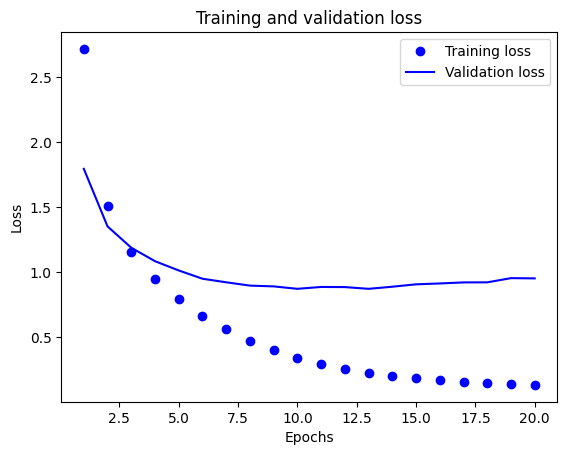

In [20]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values)+1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

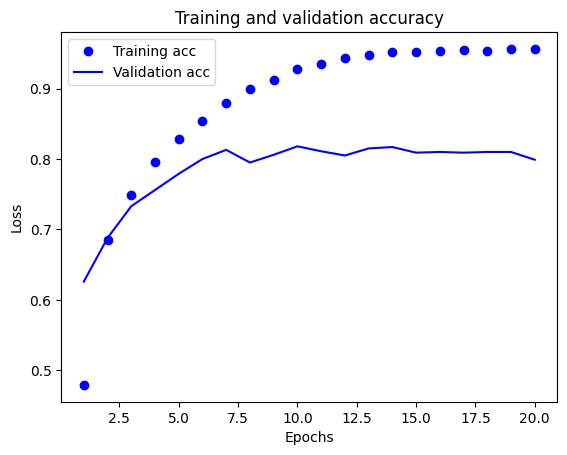

In [21]:
import matplotlib.pyplot as plt

history_dict = history.history
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(loss_values)+1)
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
model = keras.Sequential([
  layers.Dense(64, activation='relu'),
  layers.Dense(64, activation='relu'),
  layers.Dense(46, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=10,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5090 - loss: 2.7065 - val_accuracy: 0.5900 - val_loss: 1.8769
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.6669 - loss: 1.5708 - val_accuracy: 0.6710 - val_loss: 1.4446
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.7239 - loss: 1.2220 - val_accuracy: 0.7250 - val_loss: 1.2500
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7791 - loss: 1.0080 - val_accuracy: 0.7330 - val_loss: 1.1542
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8121 - loss: 0.8422 - val_accuracy: 0.7660 - val_loss: 1.0556
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8436 - loss: 0.7042 - val_accuracy: 0.7840 - val_loss: 0.9766
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8711 - loss: 0.5877 - val_accuracy: 0.7840 - val_loss: 0.9552
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8945 - loss: 0.4904 - val_accuracy: 0.8070 - v

In [23]:
y_pred = model.predict(X_test)
print(y_pred.shape)
print(y_pred[:3])

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
(2246, 46)
[[7.38432936e-05 3.56784149e-04 1.31215620e-06 9.49766815e-01
  3.98963802e-02 1.74115594e-05 1.24772589e-04 8.58994099e-05
  3.95739358e-03 2.08438491e-04 4.21200268e-04 5.99878200e-04
  2.82524124e-04 4.79753595e-04 1.01270052e-04 3.92614174e-06
  1.70535452e-04 2.89714426e-05 1.16374504e-04 2.46234471e-04
  6.66250417e-04 4.28230822e-04 4.31453445e-05 1.71552339e-04
  2.80944969e-05 6.70428708e-05 4.44152465e-06 6.90265506e-06
  7.36744696e-05 7.81741255e-05 4.95522632e-04 7.53255808e-05
  9.12703854e-06 1.51090280e-05 2.92740762e-04 1.28586489e-05
  3.00078711e-04 1.20693339e-05 6.41033839e-05 9.91072302e-05
  2.14614829e-05 5.08876037e-05 1.57413488e-05 1.68780025e-05
  6.20581432e-06 5.56212945e-06]
 [5.73876360e-03 4.32463326e-02 9.69972555e-03 1.39874112e-06
  3.29226558e-03 3.32544222e-02 2.17717681e-02 4.38328061e-05
  7.81302166e-04 8.28354582e-02 5.88334382e-01 3.08878429e-04
  3.96196614e-04 9.58612072e-04 1.54086424e-03 1.

In [24]:
for i in range(3):
  print(np.argmax(y_pred[i]),np.argmax(y_test[i]))


3 3
10 10
1 1


In [25]:
results = model.evaluate(X_test, y_test)
print(results)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7827 - loss: 0.9533
[0.9533498883247375, 0.7827248573303223]


In [26]:
results = model.evaluate(partial_X_train, partial_y_train)
print(results)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9419 - loss: 0.2930
[0.2930064797401428, 0.9418691992759705]


In [27]:
results = model.evaluate(X_val, y_val)
print(results)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8100 - loss: 0.8750
[0.8749517202377319, 0.8100000023841858]


In [28]:
model = keras.Sequential([
  layers.Dense(64, activation='relu'),
  layers.Dense(46, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.5348 - loss: 2.6953 - val_accuracy: 0.6430 - val_loss: 1.9443
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.6973 - loss: 1.5980 - val_accuracy: 0.7130 - val_loss: 1.4195
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7606 - loss: 1.1893 - val_accuracy: 0.7430 - val_loss: 1.1858
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8028 - loss: 0.9555 - val_accuracy: 0.7760 - val_loss: 1.0629
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8366 - loss: 0.7931 - val_accuracy: 0.7950 - val_loss: 0.9809
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8667 - loss: 0.6695 - val_accuracy: 0.8080 - val_loss: 0.9257
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8829 - loss: 0.5735 - val_accuracy: 0.8140 - val_loss: 0.8850
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.9008 - loss: 0.4948 - val_accuracy: 0.8190 - v

In [29]:
model = keras.Sequential([
  layers.Dense(32, activation='relu'),
  layers.Dense(46, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.4838 - loss: 3.0662 - val_accuracy: 0.6020 - val_loss: 2.4769
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6657 - loss: 2.1224 - val_accuracy: 0.6550 - val_loss: 1.9010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7063 - loss: 1.6291 - val_accuracy: 0.6970 - val_loss: 1.5457
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7448 - loss: 1.3126 - val_accuracy: 0.7260 - val_loss: 1.3361
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.7793 - loss: 1.1097 - val_accuracy: 0.7480 - val_loss: 1.2029
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8044 - loss: 0.9645 - val_accuracy: 0.7790 - val_loss: 1.1136
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8297 - loss: 0.8509 - val_accuracy: 0.7950 - val_loss: 1.0540
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8478 - loss: 0.7574 - val_accuracy: 0.7880 - v

In [30]:
results = model.evaluate(X_test, y_test)
print(results)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7992 - loss: 0.8981
[0.898110568523407, 0.799198567867279]


# PyTorch

In [46]:
from functools import partial
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score

class TorchModel(nn.Module):
  def __init__(self):
    super(TorchModel, self).__init__()
    self.fc1 = nn.Linear(10000, 32)
    self.fc2 = nn.Linear(32, 46)
    self.relu = nn.ReLU()
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    x = self.softmax(x)
    return x

model = TorchModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters())

X_train = tokenizer.sequences_to_matrix(train_data)
X_test = tokenizer.sequences_to_matrix(test_data)
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)
n_val = 1000
X_val = X_train[:n_val]
partial_X_train = X_train[n_val:]
y_val = y_train[:n_val]
partial_y_train = y_train[n_val:]


partial_X_train = torch.tensor(partial_X_train, dtype=torch.float32)
partial_y_train = torch.tensor(partial_y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

num_epochs = 100
batch_size = 512

for epoch in range(num_epochs):
  for i in range(0, len(partial_X_train), batch_size):
    batch_X = partial_X_train[i:i+batch_size]
    batch_y = partial_y_train[i:i+batch_size]
    optimizer.zero_grad()
    outputs = model(batch_X)
    loss = criterion(outputs, batch_y)
    loss.backward()
    optimizer.step()
  val_loss = criterion(model(X_val), y_val)
  print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

Epoch [1/100], Loss: 3.1742, Val Loss: 3.1883
Epoch [2/100], Loss: 3.1303, Val Loss: 3.1571
Epoch [3/100], Loss: 3.1194, Val Loss: 3.1466
Epoch [4/100], Loss: 3.1065, Val Loss: 3.1356
Epoch [5/100], Loss: 3.1005, Val Loss: 3.1342
Epoch [6/100], Loss: 3.0948, Val Loss: 3.1331
Epoch [7/100], Loss: 3.0947, Val Loss: 3.1307
Epoch [8/100], Loss: 3.0924, Val Loss: 3.1320
Epoch [9/100], Loss: 3.0923, Val Loss: 3.1336
Epoch [10/100], Loss: 3.0917, Val Loss: 3.1364
Epoch [11/100], Loss: 3.0894, Val Loss: 3.1403
Epoch [12/100], Loss: 3.0857, Val Loss: 3.1354
Epoch [13/100], Loss: 3.0857, Val Loss: 3.1346
Epoch [14/100], Loss: 3.0857, Val Loss: 3.1355
Epoch [15/100], Loss: 3.0856, Val Loss: 3.1348
Epoch [16/100], Loss: 3.1177, Val Loss: 3.1567
Epoch [17/100], Loss: 3.0773, Val Loss: 3.1289
Epoch [18/100], Loss: 3.0690, Val Loss: 3.1145
Epoch [19/100], Loss: 3.0660, Val Loss: 3.1137
Epoch [20/100], Loss: 3.0659, Val Loss: 3.1169
Epoch [21/100], Loss: 3.0657, Val Loss: 3.1157
Epoch [22/100], Loss: 

In [47]:
with torch.no_grad():
  outputs = model(X_test)
  _, predicted = torch.max(outputs, 1)
  print(accuracy_score(test_labels, predicted))

0.7813891362422084
